1.Write a code to create a line chart showing the stock price movement over 5 days: [50, 52, 51, 55, 53] ?


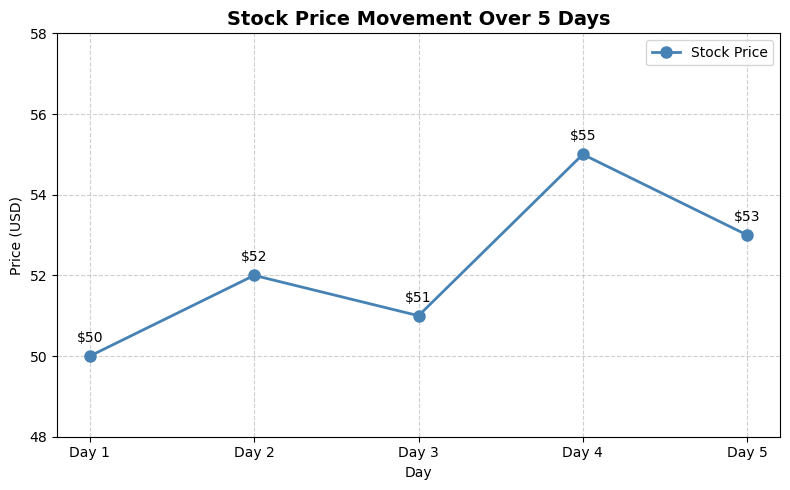

In [1]:
import matplotlib.pyplot as plt

# Stock price data
days = ['Day 1', 'Day 2', 'Day 3', 'Day 4', 'Day 5']
prices = [50, 52, 51, 55, 53]

# Create the plot
plt.figure(figsize=(8, 5))
plt.plot(days, prices, marker='o', color='steelblue', linewidth=2, markersize=8, label='Stock Price')

# Annotate each point with its value
for i, price in enumerate(prices):
    plt.annotate(f'${price}', (days[i], prices[i]),
                 textcoords="offset points", xytext=(0, 10),
                 ha='center', fontsize=10)

# Labels and formatting
plt.title('Stock Price Movement Over 5 Days', fontsize=14, fontweight='bold')
plt.xlabel('Day')
plt.ylabel('Price (USD)')
plt.ylim(48, 58)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

2.Generate a pie chart to show the distribution of survey respondents by favorite color: Red (40), Blue (30), Green (20), Yellow (10) ?

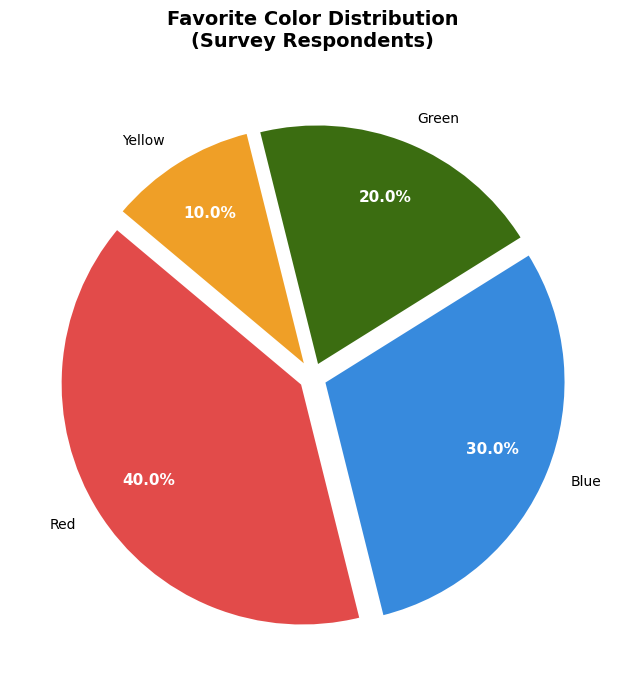

In [2]:
import matplotlib.pyplot as plt

# Survey data
colors = ['Red', 'Blue', 'Green', 'Yellow']
respondents = [40, 30, 20, 10]
color_map = ['#E24B4A', '#378ADD', '#3B6D11', '#EF9F27']

# Create the pie chart
plt.figure(figsize=(7, 7))
wedges, texts, autotexts = plt.pie(
    respondents,
    labels=colors,
    colors=color_map,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    explode=(0.05, 0.05, 0.05, 0.05)   # slight separation for each slice
)

# Style the percentage labels
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

plt.title('Favorite Color Distribution\n(Survey Respondents)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Calculate Summary Statistics using sample data ?

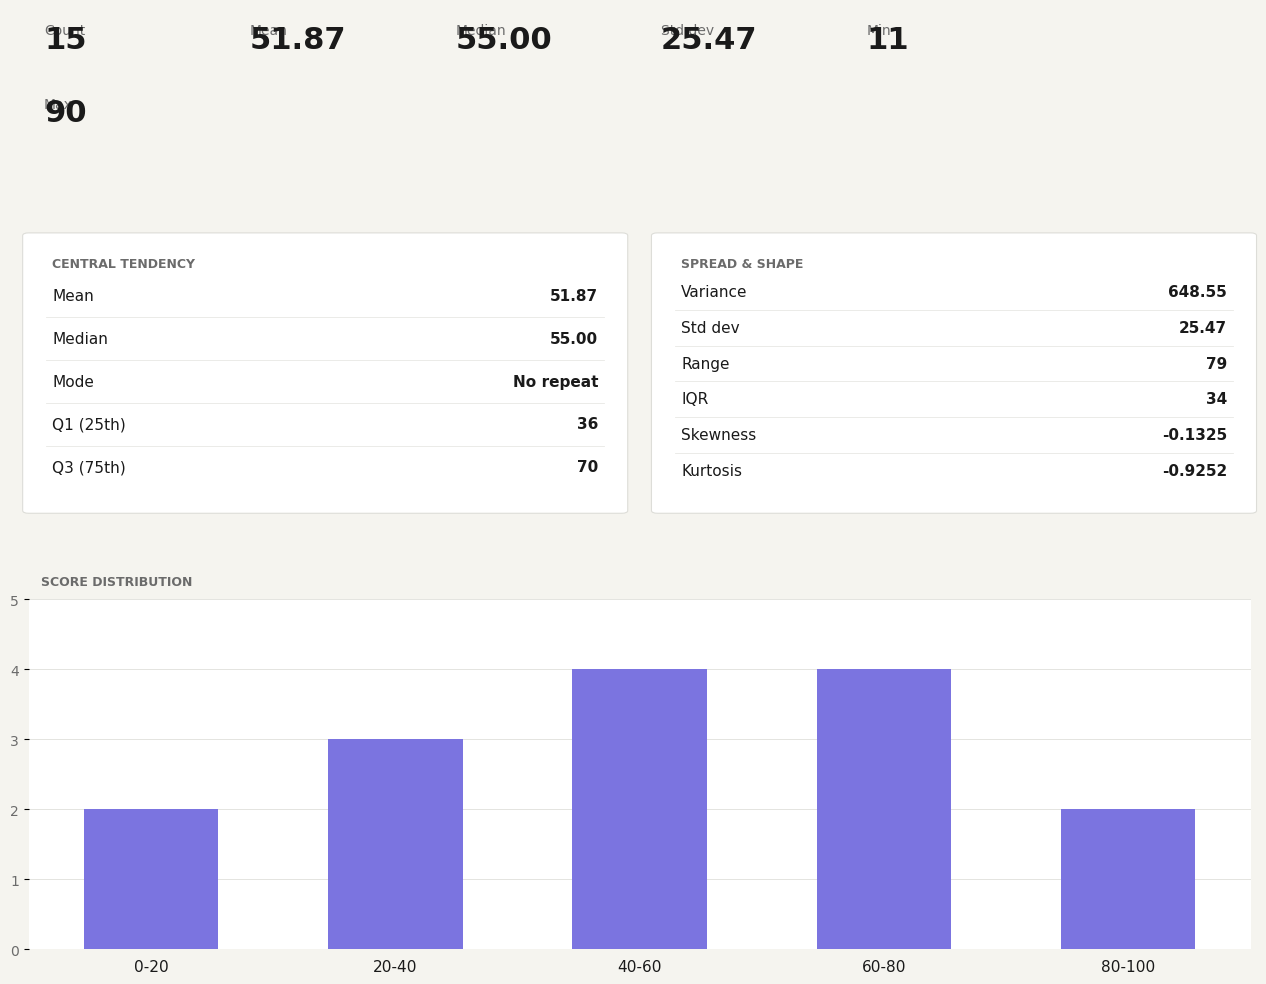

Dashboard saved as summary_dashboard.png


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch

# Data
data   = [23, 45, 67, 12, 89, 34, 56, 78, 90, 11, 43, 65, 72, 38, 55]
scores = pd.Series(data)

# Stats
n        = int(scores.count())
mean     = scores.mean()
median   = scores.median()
std      = scores.std()
variance = scores.var()
mn       = int(scores.min())
mx       = int(scores.max())
rng      = mx - mn
q1       = scores.quantile(0.25)
q3       = scores.quantile(0.75)
iqr      = q3 - q1
skew     = scores.skew()
kurt     = scores.kurtosis()

# Colors
BG       = '#F5F4EF'
WHITE    = '#FFFFFF'
PURPLE   = '#7B74E0'
TEXT_DRK = '#1A1A1A'
TEXT_MUT = '#6B6B6B'

# Helper: blank card background
def draw_card(ax, bg=BG):
    ax.set_facecolor(bg)
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

# Helper: KPI card
def kpi_card(ax, label, value):
    draw_card(ax)
    ax.text(0.08, 0.78, label, transform=ax.transAxes,
            fontsize=10, color=TEXT_MUT, va='top')
    ax.text(0.08, 0.30, value, transform=ax.transAxes,
            fontsize=22, fontweight='bold', color=TEXT_DRK, va='bottom')

# Helper: stat table card
def stat_table(ax, title, rows):
    draw_card(ax, WHITE)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    rect = FancyBboxPatch(
        (0, 0), 1, 1,
        boxstyle="round,pad=0.01",
        linewidth=0.8,
        edgecolor='#DDDDD8',
        facecolor=WHITE,
        transform=ax.transAxes,
        clip_on=False
    )
    ax.add_patch(rect)
    ax.text(0.04, 0.92, title, transform=ax.transAxes,
            fontsize=9, fontweight='bold', color=TEXT_MUT, va='top')
    row_h   = 0.78 / len(rows)
    y_start = 0.86
    for i, (lbl, val) in enumerate(rows):
        y = y_start - i * row_h - row_h * 0.5
        ax.text(0.04, y, lbl, transform=ax.transAxes,
                fontsize=11, color=TEXT_DRK, va='center')
        ax.text(0.96, y, val, transform=ax.transAxes,
                fontsize=11, fontweight='bold', color=TEXT_DRK,
                va='center', ha='right')
        if i < len(rows) - 1:
            yd = y - row_h * 0.5
            ax.plot([0.03, 0.97], [yd, yd],          # ✅ FIXED LINE
                    color='#E8E8E4', linewidth=0.6,
                    transform=ax.transAxes)

# Layout
fig = plt.figure(figsize=(13, 10), facecolor=BG)
fig.subplots_adjust(left=0.03, right=0.97, top=0.97, bottom=0.03,
                    hspace=0.35, wspace=0.03)

gs = gridspec.GridSpec(3, 1, height_ratios=[1.1, 2.2, 2.8], figure=fig)

# Row 1: KPI cards
gs_top = gridspec.GridSpecFromSubplotSpec(
    2, 6, subplot_spec=gs[0], wspace=0.06, hspace=0.15
)
kpis_r1 = [
    ('Count',   str(n)),
    ('Mean',    f'{mean:.2f}'),
    ('Median',  f'{median:.2f}'),
    ('Std dev', f'{std:.2f}'),
    ('Min',     str(mn)),
]
for col, (lbl, val) in enumerate(kpis_r1):
    ax = fig.add_subplot(gs_top[0, col])
    kpi_card(ax, lbl, val)

ax_max = fig.add_subplot(gs_top[1, 0])
kpi_card(ax_max, 'Max', str(mx))
for col in range(1, 6):
    ax_blank = fig.add_subplot(gs_top[1, col])
    ax_blank.set_visible(False)

# Row 2: Central Tendency & Spread
gs_mid = gridspec.GridSpecFromSubplotSpec(
    1, 2, subplot_spec=gs[1], wspace=0.06
)
central_rows = [
    ('Mean',      f'{mean:.2f}'),
    ('Median',    f'{median:.2f}'),
    ('Mode',      'No repeat'),
    ('Q1 (25th)', f'{q1:.0f}'),
    ('Q3 (75th)', f'{q3:.0f}'),
]
spread_rows = [
    ('Variance', f'{variance:.2f}'),
    ('Std dev',  f'{std:.2f}'),
    ('Range',    f'{rng}'),
    ('IQR',      f'{iqr:.0f}'),
    ('Skewness', f'{skew:.4f}'),
    ('Kurtosis', f'{kurt:.4f}'),
]
ax_c = fig.add_subplot(gs_mid[0])
stat_table(ax_c, 'CENTRAL TENDENCY', central_rows)

ax_s = fig.add_subplot(gs_mid[1])
stat_table(ax_s, 'SPREAD & SHAPE', spread_rows)

# Row 3: Histogram
ax_hist = fig.add_subplot(gs[2])
ax_hist.set_facecolor(WHITE)
for sp in ax_hist.spines.values():
    sp.set_visible(False)

bins       = [0, 20, 40, 60, 80, 100]
bin_labels = ['0-20', '20-40', '40-60', '60-80', '80-100']
counts     = [sum(1 for v in data if bins[i] <= v < bins[i+1]) for i in range(len(bins)-1)]
counts[-1] += sum(1 for v in data if v == 100)

x = np.arange(len(bin_labels))
ax_hist.bar(x, counts, color=PURPLE, width=0.55, zorder=3)
ax_hist.set_xticks(x)
ax_hist.set_xticklabels(bin_labels, fontsize=11, color=TEXT_DRK)
ax_hist.set_yticks(range(0, max(counts) + 2))
ax_hist.yaxis.set_tick_params(labelsize=10, labelcolor=TEXT_MUT)
ax_hist.xaxis.set_tick_params(bottom=False)
ax_hist.yaxis.grid(True, color='#E4E4E0', linewidth=0.7, zorder=0)
ax_hist.set_axisbelow(True)
ax_hist.text(0.01, 1.04, 'SCORE DISTRIBUTION',
             transform=ax_hist.transAxes,
             fontsize=9, fontweight='bold', color=TEXT_MUT)

plt.savefig('summary_dashboard.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Dashboard saved as summary_dashboard.png")